# FARSITE Fire Spread Simulation — New Ignition

This notebook runs a fully self-contained [FARSITE](https://research.fs.usda.gov/firelab/products/dataandtools/farsite) fire spread simulation starting from a user-defined ignition point. It interfaces with the [WIFIRE Firemap](https://firemap.sdsc.edu/) platform REST API.

**Steps:**
1. Install dependencies via `install_packages.sh`
2. Import libraries and set the working directory
3. Define ignition location and fire weather parameters
4. Query the Firemap endpoint and run the FARSITE simulation
5. Plot fire perimeter progression over time
6. Export and extract perimeter shapefiles
```

## 1. Install Dependencies

Run `install_packages.sh` to install the required Python packages. This only needs to be run once. 

In [1]:
!./install_packages.sh

## 2. Imports and Environment Setup

Imports required libraries and sets the working directory to the notebook's location.

In [4]:
import os
import sys
import json
import time
import zipfile
import io
import subprocess
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import requests
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from pathlib import Path
from shapely.geometry import shape, Point, Polygon, MultiPolygon
import contextily as ctx
import base64

# Ensure working directory is the notebook directory
os.chdir(Path(os.path.abspath('')))

print('Imports OK')
print(f'Working directory: {Path.cwd()}')

Imports OK
Working directory: /home/jovyan/work/Fire_Risk_Scenario


## 3. Define Ignition Parameters

These will be passed to the `ignition()` function in the next section.

In [3]:
IGNITION_LAT = 38.9014 
IGNITION_LON = -120.0306
FIREMAP_USERNAME = 'YOUR_USERNAME'
FIREMAP_PASSWORD = 'YOUR_PASSWORD'

## 4. Run FARSITE From Ignition Point

In [4]:
def ignition(lat, lon, username, password,
             temperature=90, relative_humidity=10,
             wind_speed=15, wind_direction=236,
             hours=4,
             one_hr=4, ten_hr=8, hundred_hr=12,
             herb=60, woody=60):
    """
    Run a FARSITE fire spread simulation from a point ignition via the Firemap API.
    Returns time-stepped fire perimeters.

    Parameters:
    - lat (float) : Latitude of the ignition point (WGS84)
    - lon (float) : Longitude of the ignition point (WGS84)
    - username (str) : Firemap authentication username
    - password (str) : Firemap authentication password
    - temperature (float) : Air temperature in degrees Farenheit
    - relative_humidity (float): Relative humidity as percentage
    - wind_speed (float) : Wind speed in mph
    - wind_direction (int) : Wind direction in degrees
    - hours (int) : Simulation duration in hours
    - one_hr (float) : 1-hour dead fuel moisture content as percentage
    - ten_hr (float) : 10-hr dead fuel moisture content as percentage
    - hundred_hr (float) : 100-hr dead fuel moisture content as percentage
    - herb (float) : Live herbaceous fuel moisture content as percentage
    - woody (float) : Live woody fuel moisture content as percentage
    
    Returns: dict or None (if API call fails)
    
    """
    

    RUNWF_URL = "https://firemap.sdsc.edu/kepler/runwf"
    PIG_URL = "https://firemap.sdsc.edu/pylaski/app/pig"
    HEADERS = {
        "Content-Type": "text/plain;charset=UTF-8",
        "Authorization": "WebView dW5kZWZpbmVkOnVuZGVmaW5lZA==",
        "Origin": "https://firemap.sdsc.edu",
        "Referer": "https://firemap.sdsc.edu/",
    }

    
    # --- Step 1: Query PIG (Probability of Ignition) ---
    pig_data = requests.get(PIG_URL, params={
        "lat": lat, "lon": lon,
        "temperature": temperature,
        "relative_humidity": relative_humidity,
    }).json()
    print(f"PIG: {pig_data['properties']['pig']}%")

    # --- Step 2: Build initial polygon for FARSITE input ---
    offset = 0.00015  # 15m
    ignition_geojson = {
        "type": "Feature",
        "properties": {},
        "geometry": {
            "type": "Polygon",
            "coordinates": [[
                [lon - offset, lat - offset],
                [lon + offset, lat - offset],
                [lon + offset, lat + offset],
                [lon - offset, lat + offset],
                [lon - offset, lat - offset],
            ]]
        }
    }

    # --- Step 3: Build FarsiteManual workflow payload ---
    n = hours * 2  # one entry per 30-min interval
    payload = {
        "wf_name": "FarsiteManual",
        "wf_param": {
            "ignition":        json.dumps(ignition_geojson),
            "windDirection":   [wind_direction]    * n,
            "windSpeed":       [wind_speed]        * n,
            "humidity":        [relative_humidity] * n,
            "temperature":     [temperature]       * n,
            "hours":           hours,
            "barriers":        json.dumps({"type": "FeatureCollection", "features": []}),
            "emberProbability": 0,
            "fuelMoisture": [{
                "model":      0,
                "one_hr":     one_hr,
                "ten_hr":     ten_hr,
                "hundred_hr": hundred_hr,
                "live_herb":  herb,
                "live_woody": woody,
            }],
            "perimeterResolution": 60,
            "fuelChanges":    "[]",
            "outputRasterType": -1,
        },
        "wf_paramset": {"fuel": "LANDFIRE FBFM40 30m 2022"},
        "reqid": 0,
        "prov": False,
        "sync": True,
    }

    # --- Step 4: POST to Firemap runwf endpoint ---
    response = requests.post(
        RUNWF_URL,
        data=json.dumps(payload),
        headers=HEADERS,
        auth=(username, password),
    )

    if response.status_code != 200:
        print(f"Error {response.status_code}: {response.text}")
        return None

    data = response.json()
    responses = data["responses"]

    # --- Step 5: Parse results ---
    # responses[0]: fire perimeters as a GeoJSON FeatureCollection (JSON string)
    # responses[1]: burned area over time
    # responses[2]: perimeter length over time
    perimeters = json.loads(responses[0]["perimeters"])
    area_data  = responses[1]
    perim_data = responses[2]

    print("\nFire perimeters:")
    for feature in perimeters["features"]:
        props = feature["properties"]
        print(f"  t={props['Elapsed_Mi']} min | Hour: {props['Hour']}")

    print("\nArea over time:")
    for t, a in zip(area_data["time"], area_data["area"]):
        print(f"  {t:>5.0f} min: {a/4047:>8.1f} acres")

    print("\nPerimeter over time:")
    for t, p in zip(perim_data["time"], perim_data["perimeter"]):
        print(f"  {t:>5.0f} min: {p/1000:>6.2f} km")

    return {
        "perimeters": perimeters,
        "area":       area_data,
        "perimeter":  perim_data,
    }

In [5]:
# Run the simulation using the parameters defined above
result = ignition(
    lat=IGNITION_LAT,
    lon=IGNITION_LON,
    username=FIREMAP_USERNAME,
    password=FIREMAP_PASSWORD,
)

PIG: 50%

Fire perimeters:
  t=30.0 min | Hour: 930.0
  t=60.0 min | Hour: 1000.0
  t=90.0 min | Hour: 1030.0
  t=120.0 min | Hour: 1100.0
  t=150.0 min | Hour: 1130.0
  t=180.0 min | Hour: 1200.0
  t=210.0 min | Hour: 1230.0
  t=240.0 min | Hour: 1300.0

Area over time:
     30 min:     25.4 acres
     60 min:     59.6 acres
     90 min:    115.9 acres
    120 min:    206.0 acres
    150 min:    287.3 acres
    180 min:    354.5 acres
    210 min:    413.4 acres
    240 min:    491.7 acres

Perimeter over time:
     30 min:   1.44 km
     60 min:   2.58 km
     90 min:   4.04 km
    120 min:   5.53 km
    150 min:   6.24 km
    180 min:   7.15 km
    210 min:   8.22 km
    240 min:   9.75 km


## Plot FARSITE Perimeter Progression

Visualizes the fire perimeters predicted by FARSITE across time.

In [6]:
def plot_perimeters(result, title="Fire Perimeter Progression"):
    """
    Plot FARSTIE fire perimeters across time.
    Returns polygon boundaries over a basemap.
    The Figure is saved to ``fire_perimeters.png``.

    Parameters:
    - result (dict) : Output from ``ignition()``
    - title (str) : Option plot title
     
    """
    perimeters = result["perimeters"]
    features = perimeters["features"]

    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Color ramp from dark red → yellow (earliest → latest)
    colors = cm.YlOrRd([i / (len(features) - 1) for i in range(len(features))])
    legend_patches = []

    for i, feature in enumerate(features):
        geom = shape(feature["geometry"])
        elapsed = feature["properties"]["Elapsed_Mi"]
        color = colors[i]

        # geopandas-free plotting via shapely
        if geom.geom_type == "MultiPolygon":
            for poly in geom.geoms:
                x, y = poly.exterior.xy
                ax.fill(x, y, alpha=0.3, color=color)
                ax.plot(x, y, color=color, linewidth=1.5)
        elif geom.geom_type == "Polygon":
            x, y = geom.exterior.xy
            ax.fill(x, y, alpha=0.3, color=color)
            ax.plot(x, y, color=color, linewidth=1.5)

        legend_patches.append(
            mpatches.Patch(color=color, label=f"{elapsed:.0f} min")
        )

    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs='EPSG:4326')

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend(handles=legend_patches, title="Elapsed Time",
              loc="upper left", fontsize=8)
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.savefig("fire_perimeters.png", dpi=150)
    plt.show()
    print("Saved: fire_perimeters.png")

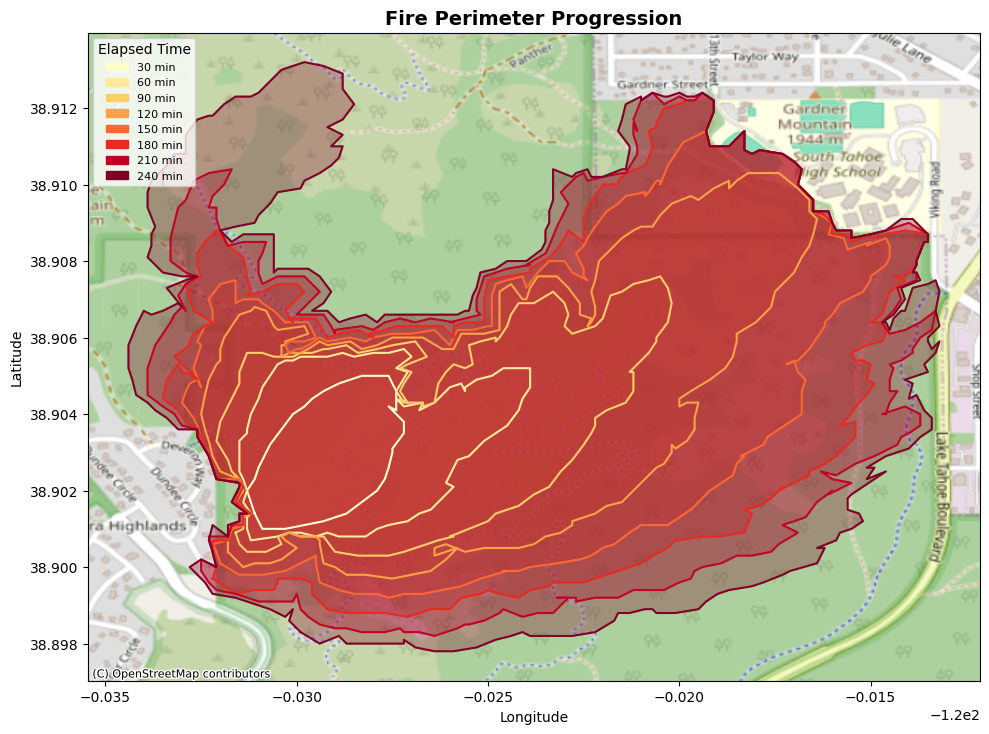

Saved: fire_perimeters.png


In [7]:
plot_perimeters(result)

## Download Perimeter Shapefiles

Downloads all simulated perimeters a a shapefile bundle (`.shp`, `.dbf`, `.prj`, `.shx`, `.fix`) from Firemap's ExportRun workflow. The shapefile components are returned as a zipfile embedded in a JSON respone. The extracted shapefile contains each time-step perimeter as separate features.

In [8]:
def download_shapefiles(result, username, password, out_dir="fire_shapefiles"):
    """
    Export all fire perimeters as a shapefile and extract to local directory.
    Returns path to the output directory containing the extracted shapefile.

    Parameters:
    - result (dict) : Output from ``ignition()``
    - username (str) : Firemap authentication username
    - password (str) : Firemap authentication password
    - out_dir (str) : Optional directory path for shapefile extraction

    Returns: str 
    
    """
    Path(out_dir).mkdir(exist_ok=True)

    export_payload = {
        "wf_name": "ExportRun",
        "wf_param": {
            "type": "shp",
            "filename": "Perimeter",
            "perimeters": json.dumps(result["perimeters"]),
            "ignition": json.dumps({
                "type": "Feature",
                "properties": {},
                "geometry": {
                    "type": "Point",
                    "coordinates": [-120.03044128417969, 38.90172091499795]
                }
            }),
            "barriers": json.dumps({"type": "FeatureCollection", "features": []}),
            "group": "fire"
        },
        "reqid": 1,
        "prov": False,
        "sync": True,
    }

    response = requests.post(
        "https://firemap.sdsc.edu/kepler/runwf",
        data=json.dumps(export_payload),
        headers={
            "Content-Type": "text/plain;charset=UTF-8",
            "Authorization": "WebView dW5kZWZpbmVkOnVuZGVmaW5lZA==",
            "Origin": "https://firemap.sdsc.edu",
            "Referer": "https://firemap.sdsc.edu/",
        },
        auth=(username, password),
    )

    b64_data = response.json()["responses"][0]["data"]
    zip_bytes = base64.b64decode(b64_data)

    with zipfile.ZipFile(io.BytesIO(zip_bytes)) as z:
        print(f"Zip contents: {z.namelist()}")
        z.extractall(out_dir)

    print(f"Extracted to: {out_dir}/")
    return out_dir

In [9]:
download_shapefiles(result, FIREMAP_USERNAME, FIREMAP_PASSWORD)

Zip contents: ['Perimeter.dbf', 'Perimeter.fix', 'Perimeter.prj', 'Perimeter.shp', 'Perimeter.shx']
Extracted to: fire_shapefiles/


'fire_shapefiles'

## Download Perimeters as GeoJSON

In [11]:
# Create GeoJSON output directory
geojson_dir = 'fire_geojsons'
Path(geojson_dir).mkdir(exist_ok=True)

# Convert ShapeFile to GeoJSON in output directory
output_shpfile = gpd.read_file('fire_shapefiles/Perimeter.shp')
output_shpfile.to_file(f'{geojson_dir}/Perimeter.geojson', driver='GeoJSON')

print('Perimeter.geojson')
print(f"Extracted to: {geojson_dir}/")

Perimeter.geojson
Extracted to: fire_geojsons/
